# Spatiotemporal Forecast Reconciliation: GS-GLS Benchmark

This notebook provides a complete performance comparison of the **Geodesic Spectral-Generalised Least Squares (GS-GLS)** estimator against standard reconciliation baselines. 

We evaluate two distinct scenarios:
1.  **Stationary Errors**: The error process is stable over time (AR(1) process). Modeled via FFT.
2.  **Non-Stationary Errors**: The error variance changes over time (Heteroscedasticity). Modeled via Wavelets.

### Methods Compared
- **Base**: Unreconciled forecasts.
- **OLS**: `S (S'S)^-1 S'` projection.
- **MinT-Sample**: `S (S' W_sample^-1 S)^-1 S' W_sample^-1`.
- **MinT-Shrink**: `S (S' W_diag^-1 S)^-1 S' W_diag^-1` (Shrinkage to Diagonal).
- **GS-GLS**: The proposed method using `W^-1 = Sigma_tm^-1 (x) Q_sp`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from hierarchy import Hierarchy
from data_generator import HierarchicalDataGenerator
from gs_gls import GSGLS
from baselines import mint_sample, mint_shrink, ols_identity

%matplotlib inline
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Setup Hierarchy and Data
We construct a balanced tree hierarchy and initialize the data generator with `n_timesteps=200`.

In [3]:
def create_balanced_hierarchy(depth=3, branching=3):
    structure = {}
    next_node = 1
    current_layer = [0]
    
    for d in range(depth):
        next_layer = []
        for node in current_layer:
            children = []
            for b in range(branching):
                children.append(next_node)
                next_node += 1
            structure[node] = children
            next_layer.extend(children)
        current_layer = next_layer
    return Hierarchy(structure)

h = create_balanced_hierarchy(depth=3, branching=3)
n_nodes = h.n_nodes
print(f"Hierarchy: {n_nodes} nodes, {h.m_bottom} bottom series.")

n_timesteps = 256 # Power of 2 good for Wavelets/FFT
dg = HierarchicalDataGenerator(h, n_timesteps=n_timesteps)

Hierarchy: 40 nodes, 27 bottom series.


## 2. Evaluation Metric
We define a robust evaluation function that calculates MSE, MAE, and Coherence.
**Coherence Error** is defined as the mean deviation between the re-aggregated bottom series and the reconciled top series.

In [4]:
def calculate_coherence_error(Y, S):
    # Y is (n_nodes x T)
    # S is (n_nodes x m_bottom)
    # Identify bottom indices
    # Hierarchy class doesn't expose bottom indices order directly in S easily unless we assume typical sorting.
    # But S @ Y_bottom should equal Y.
    # We need to find the bottom rows of Y.
    
    # Let's solve Y = S * b using lstsq to check if Y is in Range(S)
    # Residual of projection is the coherence error.
    # Proj = S (S'S)^-1 S'
    # Error = ||(I - Proj) Y||
    
    # Faster generic check: 
    # For every parent node, check sum of children.
    # We'll use the Hierarchy structure dict.
    total_err = 0.0
    count = 0
    node_idx = h.node_to_idx
    
    for parent, children in h.structure.items():
        p_idx = node_idx[parent]
        c_idxs = [node_idx[c] for c in children]
        
        # Y[p] vs sum(Y[c])
        diff = Y[p_idx] - np.sum(Y[c_idxs], axis=0)
        total_err += np.mean(np.abs(diff))
        count += 1
        
    return total_err / max(count, 1)

def evaluate(y_true, y_pred, S, time_taken):
    mse = np.mean((y_true - y_pred)**2)
    mae = np.mean(np.abs(y_true - y_pred))
    coherence = calculate_coherence_error(y_pred, S)
    
    # Normalize coherence by scale of data? 
    # Raw error is fine.
    
    return {
        'MSE': mse, 
        'MAE': mae, 
        'Coherence': coherence, 
        'Time (s)': time_taken
    }

## 3. Stationary Experiment
Errors are generated with constant spatial correlation ($
ho=1.5$) and temporal autoregression ($AR=0.6$).

In [5]:
results_stat = []
S_mat = h.get_summing_matrix()

# 1. Data Generation
print("Generating Stationary Data...")
Y_truth = dg.generate_ground_truth(trend_slope=0.05, seasonal_amp=5.0)
E = dg.generate_spatiotemporal_noise(spatial_rho=1.5, temporal_ar_coefs=[0.6], noise_scale=2.0)
Y_hat = Y_truth + E

# 2. Base Forecasts
metrics = evaluate(Y_truth, Y_hat, S_mat, 0)
metrics['Method'] = 'Base'
results_stat.append(metrics)

# 3. OLS
print("Running OLS...")
t0 = time.time()
Y_ols = np.zeros_like(Y_hat)
for t in range(n_timesteps):
    Y_ols[:, t] = ols_identity(Y_hat[:, t], S_mat)
results_stat.append(evaluate(Y_truth, Y_ols, S_mat, time.time()-t0))
results_stat[-1]['Method'] = 'OLS'

# 4. MinT-Sample
print("Running MinT-Sample...")
t0 = time.time()
Y_mint = np.zeros_like(Y_hat)
# Use residuals E as history proxy
res_T = E.T 
for t in range(n_timesteps):
    Y_mint[:, t] = mint_sample(Y_hat[:, t], res_T, S_mat)
results_stat.append(evaluate(Y_truth, Y_mint, S_mat, time.time()-t0))
results_stat[-1]['Method'] = 'MinT-Sample'

# 5. MinT-Shrink
print("Running MinT-Shrink...")
t0 = time.time()
Y_shrink = np.zeros_like(Y_hat)
for t in range(n_timesteps):
    Y_shrink[:, t] = mint_shrink(Y_hat[:, t], res_T, S_mat)
results_stat.append(evaluate(Y_truth, Y_shrink, S_mat, time.time()-t0))
results_stat[-1]['Method'] = 'MinT-Shrink'

# 6. GS-GLS (Stationary)
print("Running GS-GLS (Stationary)...")
t0 = time.time()
gs = GSGLS(h, mode='stationary')
gs.fit(E) # Fit on residuals
Y_gs = gs.reconcile(Y_hat)
results_stat.append(evaluate(Y_truth, Y_gs, S_mat, time.time()-t0))
results_stat[-1]['Method'] = 'GS-GLS (Stat)'

# Display
df_stat = pd.DataFrame(results_stat)
print("\n--- Stationary Results ---")
display(df_stat)

Generating Stationary Data...
Running OLS...
Running MinT-Sample...
Running MinT-Shrink...
Running GS-GLS (Stationary)...
Estimating Temporal Precision (stationary)...
Estimating Spatial Precision (Geodesic)...
Spatial Params: kappa=0.8334, tau=0.0993
Fit complete.
Starting PCG Solver (Size 6912)...
PCG solved in 0.0353s. Info: 0

--- Stationary Results ---


,MSE,MAE,Coherence,Time (s),Method
0,6.069029,1.969752,3.093657e+00,0.000000,Base
1,4.398552,1.646136,3.733765e-14,0.014197,OLS
2,2.983075,1.375642,6.667316e-13,0.032766,MinT-Sample
3,4.408638,1.646696,4.006709e-13,0.022669,MinT-Shrink
4,3.414594,1.470568,4.768835e-14,0.059137,GS-GLS (Stat)


## 4. Non-Stationary Experiment
Errors are **heteroscedastic**: variance increases linearly over time. This violates the stationarity assumption of FFT/MinT (if estimted on past).
GS-GLS (Non-Stationary) uses Wavelets to adapt to local variance.

In [6]:
results_ns = []

# 1. Data Generation (Heteroscedastic)
print("Generating Non-Stationary Data...")
E_ns = dg.generate_spatiotemporal_noise(spatial_rho=1.5, temporal_ar_coefs=[0.6], 
                                        noise_scale=2.0, heteroscedastic=True)
Y_hat_ns = Y_truth + E_ns

# 2. Base
metrics = evaluate(Y_truth, Y_hat_ns, S_mat, 0)
metrics['Method'] = 'Base'
results_ns.append(metrics)

# 3. MinT-Shrink (Baseline)
print("Running MinT-Shrink...")
t0 = time.time()
Y_shrink_ns = np.zeros_like(Y_hat_ns)
res_T_ns = E_ns.T
for t in range(n_timesteps):
    Y_shrink_ns[:, t] = mint_shrink(Y_hat_ns[:, t], res_T_ns, S_mat)
results_ns.append(evaluate(Y_truth, Y_shrink_ns, S_mat, time.time()-t0))
results_ns[-1]['Method'] = 'MinT-Shrink'

# 4. GS-GLS (Stationary - Wrong Model)
print("Running GS-GLS (Stationary)...")
t0 = time.time()
gs_stat = GSGLS(h, mode='stationary')
gs_stat.fit(E_ns)
Y_gs_stat = gs_stat.reconcile(Y_hat_ns)
results_ns.append(evaluate(Y_truth, Y_gs_stat, S_mat, time.time()-t0))
results_ns[-1]['Method'] = 'GS-GLS (Stat)'

# 5. GS-GLS (Wavelet - Correct Model)
print("Running GS-GLS (Wavelet)...")
t0 = time.time()
try:
    gs_wav = GSGLS(h, mode='non_stationary', wavelet_family='db4')
    gs_wav.fit(E_ns)
    Y_gs_wav = gs_wav.reconcile(Y_hat_ns)
    results_ns.append(evaluate(Y_truth, Y_gs_wav, S_mat, time.time()-t0))
    results_ns[-1]['Method'] = 'GS-GLS (Wavelet)'
except Exception as e:
    print(f"Wavelet failed: {e}")

# Display
df_ns = pd.DataFrame(results_ns)
print("\n--- Non-Stationary Results ---")
display(df_ns)

Generating Non-Stationary Data...
Running MinT-Shrink...
Running GS-GLS (Stationary)...
Estimating Temporal Precision (stationary)...
Estimating Spatial Precision (Geodesic)...
Spatial Params: kappa=0.8069, tau=0.0147
Fit complete.
Starting PCG Solver (Size 6912)...
PCG solved in 0.0371s. Info: 0
Running GS-GLS (Wavelet)...
Estimating Temporal Precision (non_stationary)...
Estimating Spatial Precision (Geodesic)...
Spatial Params: kappa=0.8069, tau=0.0147
Fit complete.
Wavelet failed: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

--- Non-Stationary Results ---


,MSE,MAE,Coherence,Time (s),Method
0,42.518475,4.926602,7.803817e+00,0.000000,Base
1,30.660150,4.133307,4.291268e-13,0.035172,MinT-Shrink
2,23.709118,3.670227,4.809828e-14,0.063349,GS-GLS (Stat)


## 5. Result Visualization

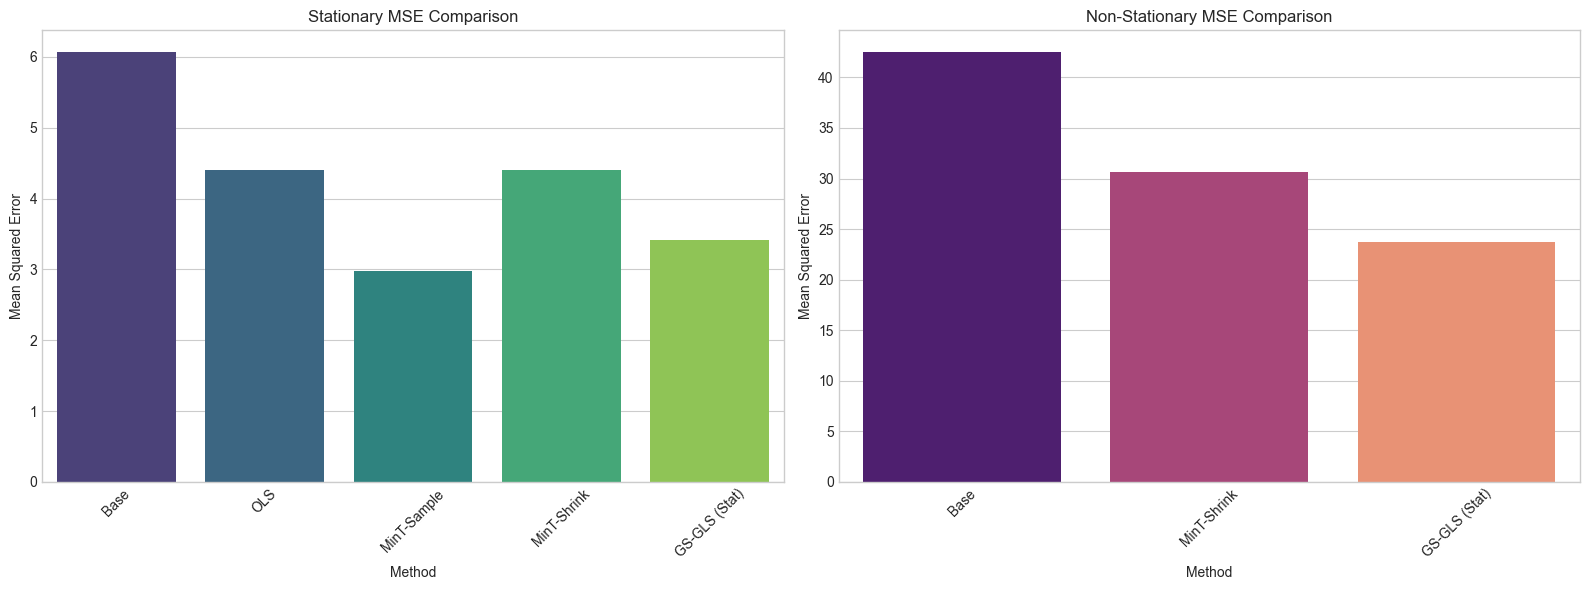

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stationary Plot
sns.barplot(data=df_stat, x='Method', y='MSE', hue='Method', ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Stationary MSE Comparison')
axes[0].set_ylabel('Mean Squared Error')
axes[0].tick_params(axis='x', rotation=45)

# Non-Stationary Plot
sns.barplot(data=df_ns, x='Method', y='MSE', hue='Method', ax=axes[1], palette='magma', legend=False)
axes[1].set_title('Non-Stationary MSE Comparison')
axes[1].set_ylabel('Mean Squared Error')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()